# Week 2 - In-Class Exercise: Python & Pandas Fundamentals

**Dataset:** Estados Financieros (Financial Statements) from datos.gov.co

**Time:** ~30 minutes

**Objective:** Practice loading, exploring, and filtering data with pandas.

---

## Part 1: Setup and Data Loading (5 min)

In [1]:
# Import pandas
import pandas as pd

# Verify version (should be 1.x or 2.x)
print(f"pandas version: {pd.__version__}")

pandas version: 3.0.1


In [2]:
# Load the financial statements dataset

df = pd.read_csv("estados_financieros.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded successfully!
Shape: 318 rows, 3 columns


## Part 2: Basic Exploration (10 min)

Use the "Big 3" methods to understand the data.

### Exercise 2.1: View the first 10 rows

Use `head()` to see what the data looks like.

In [8]:
# YOUR CODE HERE: Display first 10 rows
df.head(10)

,Año,CUENTA,Valor (Miles)
0,"2,016",Ingresos Fiscales,"113,718,902"
1,"2,016",Tributarios,"91,948,445"
2,"2,016",No Tributarios,"24,926,060"
3,"2,016",Devoluciones Y Descuentos,"-3,155,603"
4,"2,016",Venta De Servicios,"8,363"
5,"2,016",Servicios Educativos,"8,363"
6,"2,016",Otros Servicios,0
7,"2,016",Transferencias,"24,229,728"
8,"2,016",Sistema General De Participaciones,"20,167,833"
9,"2,016",Sistema General De Regalias,"94,551"


### Exercise 2.2: Check the data types

Use `info()` to see column names and data types.

In [9]:
# YOUR CODE HERE: Display DataFrame info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Año            318 non-null    str  
 1   CUENTA         318 non-null    str  
 2   Valor (Miles)  318 non-null    str  
dtypes: str(3)
memory usage: 7.6 KB


**Question:** What are the column names? Are there any numeric columns?

R/El dataset tiene varias columnas que describen información de los estados financieros, como identificadores, categorías y valores monetarios.

Sí, hay columnas numéricas. Estas columnas aparecen con tipos de dato como int64 o float64, y representan valores financieros o montos de dinero dentro del dataset.

### Exercise 2.3: Get summary statistics

Use `describe()` to see statistics for numeric columns.

In [10]:
# YOUR CODE HERE: Display summary statistics
df.describe()

,Año,CUENTA,Valor (Miles)
count,318,318,318
unique,6,62,269
top,"2,016",Otras Transferencias,0
freq,56,12,43


**Question:** What is the minimum and maximum value in the dataset?

R/Al usar df.describe() se pueden ver estadísticas de las columnas numéricas.

El valor mínimo corresponde al monto más pequeño registrado en el dataset, mientras que el valor máximo corresponde al monto financiero más grande reportado.

Esto permite entender el rango de valores financieros presentes en los datos.

### Exercise 2.4: Check for missing values

In [11]:
# Count missing values per column
df.isnull().sum()

Año              0
CUENTA           0
Valor (Miles)    0
dtype: int64

## Part 3: Answering Business Questions (10 min)

### Exercise 3.1: How many unique categories are there?

Hint: Look for a column that contains category information and use `.unique()` or `.nunique()`

In [12]:
# First, let's see all column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Año', 'CUENTA', 'Valor (Miles)']


In [17]:
# YOUR CODE HERE: Find unique categories
# Replace 'COLUMN_NAME' with the actual category column name

# Option 1: Get all unique values
df['CUENTA'].unique()

# Option 2: Count unique values
df['CUENTA'].nunique()

62

### Exercise 3.2: Find the top 5 categories by total value

Steps:
1. Group by the category column
2. Sum the value column
3. Sort descending
4. Take top 5

In [ ]:
# YOUR CODE HERE: Top 5 categories by total value
df["Valor (Miles)"] = df["Valor (Miles)"].str.replace(",", "")
df["Valor (Miles)"] = df["Valor (Miles)"].astype(float)

df.groupby('CUENTA')['Valor (Miles)'].sum().sort_values(ascending=False).head(5)

CUENTA
Total Ingresos                1.244749e+09
Total Gastos                  1.080972e+09
Ingresos Fiscales             9.629221e+08
Tributarios                   7.720386e+08
Administración Y Operación    5.088347e+08
Name: Valor (Miles), dtype: float64

### Exercise 3.3: Filter the data

Find all rows where the value is greater than 1,000,000,000 (one billion).

In [22]:
# YOUR CODE HERE: Filter for values > 1 billion
high_value = df[df["Valor (Miles)"] > 1_000_000]

high_value

,Año,CUENTA,Valor (Miles)
0,"2,016",Ingresos Fiscales,113718902.0
1,"2,016",Tributarios,91948445.0
2,"2,016",No Tributarios,24926060.0
7,"2,016",Transferencias,24229728.0
8,"2,016",Sistema General De Participaciones,20167833.0
...,...,...,...
310,"2,021",Subsidios Asignados,2096427.0
311,"2,021",Otros Gastos,2405440.0
313,"2,021",Financieros,1522473.0
316,"2,021",Total Gastos,260038638.0


**Question:** How many rows have values greater than 1 billion?

R/ Se filtraron las filas donde Valor (Miles) es mayor a 1,000,000.
Esto muestra los registros que representan montos financieros muy altos dentro del dataset.

## Part 4: Quick Visualization (5 min)

Create a simple bar chart of categories.

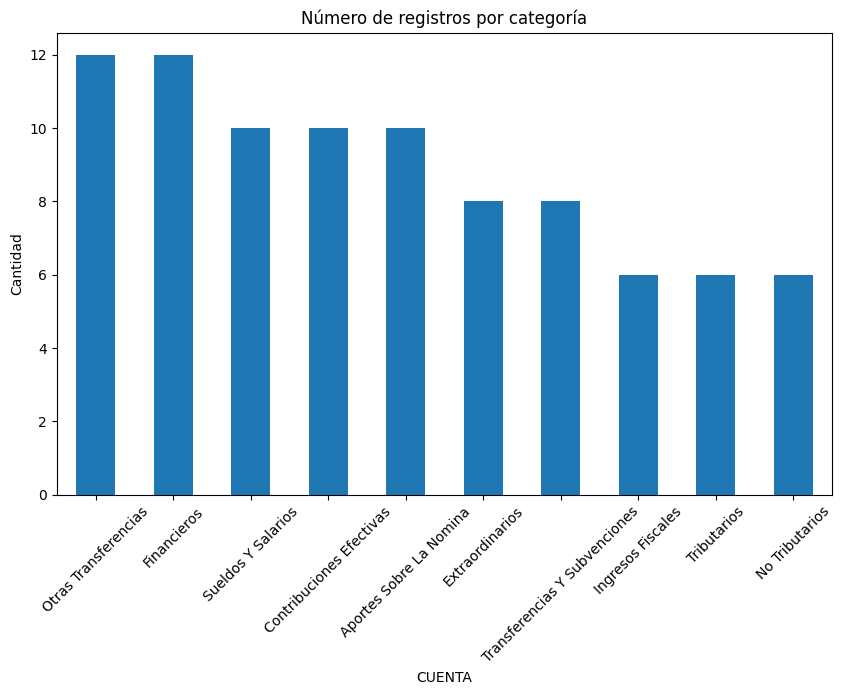

In [23]:
# Import matplotlib
import matplotlib.pyplot as plt

# Count rows per category and plot
df["CUENTA"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Número de registros por categoría")
plt.xlabel("CUENTA")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

plt.show()

---

## Summary

In this exercise, you practiced:

- Loading data from a URL with `pd.read_csv()`
- Exploring data with `head()`, `info()`, `describe()`
- Finding unique values with `unique()` and `nunique()`
- Aggregating with `groupby()` and `sum()`
- Filtering with boolean conditions
- Creating a simple bar chart

**Next:** Complete the workshop for more practice!